In [1]:
from database.adatabase import ADatabase
import pandas as pd
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [3]:
training_year = 2020
training_years = 7
holding_period = 65
rr = 0
risk = 1
tickers = sp100["ticker"].values
remodel = False
factors = ["rolling_10","rolling_20","rolling_60","rolling_100"]
## model_data

In [4]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["rolling_10"] = ticker_prices["adjclose"].rolling(10).mean()
        ticker_prices["rolling_20"] = ticker_prices["adjclose"].rolling(20).mean()
        ticker_prices["rolling_60"] = ticker_prices["adjclose"].rolling(60).mean()
        ticker_prices["rolling_100"] = ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-holding_period)
        prices.append(ticker_prices.iloc[100:])
    except:
        continue
market.disconnect()

model_prep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:25<00:00,  3.92it/s]


In [5]:
training_data = pd.concat(prices)
model_data = training_data[(training_data["year"]<=training_year) & (training_data["year"]>=training_year-training_years)].dropna()
model_data = model_data.groupby(["date","ticker"]).first().reset_index()

In [6]:
model_data

,date,ticker,adjclose,year,quarter,month,week,weekday,rolling_10,rolling_20,rolling_60,rolling_100,y
0,2013-01-02 00:00:00+00:00,AAPL,16.770116,2013,1,1,1,2,15.942947,15.881439,16.232705,16.630762,13.855819
1,2013-01-02 00:00:00+00:00,ABT,26.011222,2013,1,1,1,2,25.546079,25.494413,25.684537,25.823304,29.787792
2,2013-01-02 00:00:00+00:00,ACN,56.658988,2013,1,1,1,2,55.676932,56.530591,55.972772,54.237215,62.804019
3,2013-01-02 00:00:00+00:00,ADBE,38.340000,2013,1,1,1,2,37.646040,36.777005,34.370090,33.724902,43.790000
4,2013-01-02 00:00:00+00:00,AIG,29.073149,2013,1,1,1,2,28.096074,27.639814,27.208923,27.119796,31.950179
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196305,2020-12-31 00:00:00+00:00,V,214.043717,2020,4,12,53,3,207.010699,205.935734,200.285516,199.600064,214.898091
196306,2020-12-31 00:00:00+00:00,VZ,49.598176,2020,4,12,53,3,49.929956,50.665275,50.129118,49.967085,50.343237
196307,2020-12-31 00:00:00+00:00,WFC,28.200776,2020,4,12,53,3,27.735435,27.539674,24.271914,23.597955,37.481843
196308,2020-12-31 00:00:00+00:00,WMT,138.113337,2020,4,12,53,3,138.620184,139.828737,139.465768,136.010499,134.512154


In [7]:
db.connect()
if remodel == True:
    db.drop("model")
    model = XGBRegressor(booster="dart",learning_rate=1)
    model.fit(model_data[factors],model_data["y"])
    pickled = pickle.dumps(model)
    db.store("model",pd.DataFrame([{"model":pickled}]))
else:
    model = pickle.loads(db.retrieve("model")["model"].iloc[0])
db.disconnect()

In [8]:
simulation = training_data[training_data["year"]>=training_year+1]
simulation["prediction"] = model.predict(simulation[factors])

In [9]:
bt_data = []
for ticker in tqdm(simulation["ticker"].unique(),desc="backtest_prep"):
    prices = simulation[simulation["ticker"]==ticker]
    prices.sort_values("date",inplace=True)
    prices["signal"] = (prices["prediction"] - prices["adjclose"]) / prices["adjclose"]
    prices["std"] = prices["adjclose"].rolling(holding_period).std()
    prices["rolling"] = prices["adjclose"].rolling(holding_period).mean()
    prices["risk"] = prices["std"] / prices["rolling"]
    prices["sell_price"] = prices["adjclose"].shift(-holding_period)
    prices["sell_date"] = prices["date"].shift(-holding_period)
    bt_data.append(prices.ffill())
sim = pd.concat(bt_data)

backtest_prep: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 32.71it/s]


In [10]:
sim

,date,adjclose,ticker,year,quarter,month,week,weekday,rolling_10,rolling_20,rolling_60,rolling_100,y,prediction,signal,std,rolling,risk,sell_price,sell_date
9340,2021-01-04 00:00:00+00:00,127.167787,AAPL,2021,1,1,1,0,131.014955,130.891629,125.622124,121.964678,131.619299,129.128616,0.015419,NaN,NaN,NaN,131.619299,2021-02-03 00:00:00+00:00
14373,2021-01-04 00:00:00+00:00,127.167787,AAPL,2021,1,1,1,0,130.478415,130.770269,125.728089,122.064420,135.009523,121.651962,-0.043374,NaN,NaN,NaN,135.009523,2021-02-04 00:00:00+00:00
4307,2021-01-04 00:00:00+00:00,127.167787,AAPL,2021,1,1,1,0,129.941875,130.694112,125.834054,122.164161,135.009523,121.651962,-0.043374,NaN,NaN,NaN,135.009523,2021-02-04 00:00:00+00:00
14374,2021-01-05 00:00:00+00:00,128.740065,AAPL,2021,1,1,1,1,129.562563,130.696568,125.977524,122.279625,135.009523,120.412247,-0.064687,NaN,NaN,NaN,135.009523,2021-02-04 00:00:00+00:00
4308,2021-01-05 00:00:00+00:00,128.740065,AAPL,2021,1,1,1,1,129.296258,130.699025,126.120994,122.384869,134.591886,130.971939,0.017336,NaN,NaN,NaN,134.591886,2021-02-05 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5028,2023-11-14 00:00:00+00:00,104.290000,XOM,2023,4,11,46,1,104.283063,106.068301,110.024926,107.746677,104.500000,110.248611,0.057135,4.493294,109.819325,0.040915,104.500000,2023-11-20 00:00:00+00:00
5029,2023-11-15 00:00:00+00:00,103.660000,XOM,2023,4,11,46,2,104.180424,105.654781,109.967190,107.758414,104.500000,110.248611,0.063560,4.546529,109.765115,0.041421,104.500000,2023-11-20 00:00:00+00:00
5030,2023-11-16 00:00:00+00:00,102.460000,XOM,2023,4,11,46,3,103.613918,105.177792,109.905144,107.755596,104.500000,110.248611,0.076016,4.604591,109.720190,0.041967,104.500000,2023-11-20 00:00:00+00:00
5031,2023-11-17 00:00:00+00:00,104.960000,XOM,2023,4,11,46,4,103.429211,104.921928,109.897977,107.769425,104.500000,110.248611,0.050387,4.633820,109.682322,0.042248,104.500000,2023-11-20 00:00:00+00:00


In [11]:
fed.connect()
benchmark = processor.column_date_processing(fed.retrieve("sp500")).rename(columns={"value":"sp500"})
yields = processor.column_date_processing(fed.retrieve("tyields")).rename(columns={"value":"yield1"})
yields["yield1"] = [(1+float(x)/100) ** (holding_period/365) - 1 for x in yields["yield1"]]
sp500_projections = fed.retrieve("sp500_v2_projections").rename(columns={"prediction":"sp500_prediction"})
fed.disconnect()

In [12]:
sim = processor.merge(sim,sp100,on="ticker")
sim = processor.merge(sim,sp500_projections,on=["year","quarter"])
sim = processor.merge(sim,benchmark,on="date")
sim = processor.merge(sim,yields,on="date").ffill().bfill()

sim["sp500_var"] = sim["sp500"].rolling(100).var()
sim["sp500_cov"] = sim["sp500"].rolling(100).cov(sim["adjclose"].rolling(100).mean())
sim["market_expected_return"] = (sim["sp500_prediction"] - sim["sp500"]) / sim["sp500"]
sim["beta"] = sim["sp500_cov"] / sim["sp500_var"]
sim["signal"] = (sim["signal"]) - sim["yield1"] + sim["beta"] * (sim["market_expected_return"]-sim["yield1"])

## post cfa
sim["abs"] = sim["signal"].abs()
sim["direction"] = sim["signal"] / sim["abs"]
positions = len(sim["GICS Sector"].unique())
sim["return"] = (sim["sell_price"] - sim["adjclose"]) / sim ["adjclose"] * (1/positions) * sim["direction"]
sim.sort_values("date",inplace=True)

In [44]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["abs"]>=rr]
trades = trades[trades["risk"]<=risk]
week_mod = int(holding_period / 5)
trades = trades[trades["week"] % week_mod == 0]
trades = trades.sort_values("abs").groupby(["date","GICS Sector"]).first().reset_index()

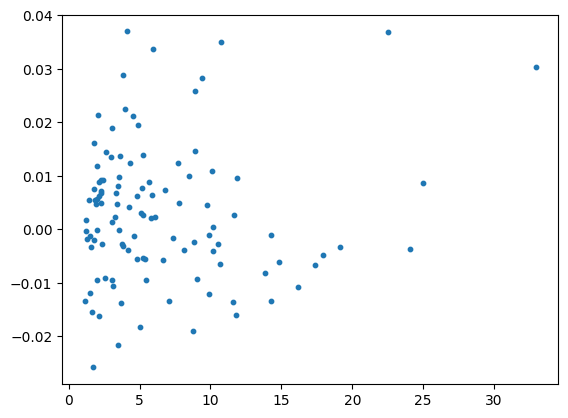

In [45]:
trades = processor.column_date_processing(trades[["date","abs","direction","std","ticker","GICS Sector","adjclose","return"]])

plt.scatter(trades["std"],trades["return"],s=10)
plt.show()


In [46]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio = processor.merge(portfolio,benchmark,on="date").dropna()
portfolio["bcr"] = (portfolio["sp500"] - portfolio["sp500"].iloc[0]) / portfolio["sp500"].iloc[0] + 1
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

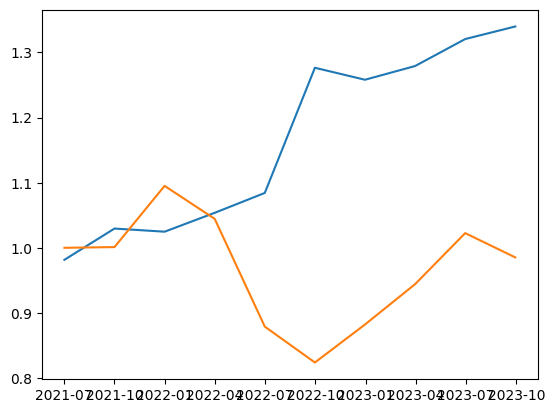

In [47]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [48]:
recommendations = trades.tail(positions)

In [49]:
recommendations

,date,abs,direction,std,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
99,2023-09-29 00:00:00+00:00,0.001601,-1.0,9.874609,META,Communication Services,300.210000,-0.012040,2023,3,9,39,4
100,2023-09-29 00:00:00+00:00,0.026666,1.0,3.002906,SBUX,Consumer Discretionary,90.763931,0.013558,2023,3,9,39,4
101,2023-09-29 00:00:00+00:00,0.008152,1.0,1.980620,PM,Consumer Staples,92.580000,-0.000196,2023,3,9,39,4
102,2023-09-29 00:00:00+00:00,0.023935,1.0,5.430718,XOM,Energy,116.518607,-0.009377,2023,3,9,39,4
103,2023-09-29 00:00:00+00:00,0.025404,-1.0,3.811143,SCHW,Financials,54.647749,-0.003181,2023,3,9,39,4
104,2023-09-29 00:00:00+00:00,0.000058,-1.0,1.535311,GILD,Health Care,74.940000,-0.001286,2023,3,9,39,4
105,2023-09-29 00:00:00+00:00,0.007352,1.0,10.561503,UPS,Industrials,154.062876,-0.002651,2023,3,9,39,4
106,2023-09-29 00:00:00+00:00,0.011451,1.0,8.452008,CRM,Information Technology,202.780000,0.010020,2023,3,9,39,4
107,2023-09-29 00:00:00+00:00,0.005986,-1.0,1.254011,DOW,Materials,51.560000,-0.000212,2023,3,9,39,4
108,2023-09-29 00:00:00+00:00,0.012495,1.0,4.288664,SPG,Real Estate,108.030000,0.012387,2023,3,9,39,4


In [50]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()